**1 - Importing libraries and loading data**

In [ ]:

# Installing additional libraries for text preprocessing
!pip install emoji
!pip install contractions


In [ ]:

# Data manipulation libraries
import pandas as pd
import numpy as np
import json
from pprint import pprint

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Text processing libraries
import emoji
import re
import contractions
from collections import Counter
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Untitled folder/archive.zip'   # change this
extract_path = '/content/drive/MyDrive/unzipped_folder'  # change this

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully!")

Unzipped successfully!


In [ ]:
# Importing raw comments and labels
df_train = pd.read_csv('/content/drive/MyDrive/unzipped_folder/data/train.tsv', sep='\t', header=None, names=['Text', 'GE_indices', 'Id']).drop('Id', axis=1)
df_val = pd.read_csv('/content/drive/MyDrive/unzipped_folder/data/dev.tsv', sep='\t', header=None, names=['Text', 'GE_indices', 'Id']).drop('Id', axis=1)
df_test = pd.read_csv('/content/drive/MyDrive/unzipped_folder/data/test.tsv', sep='\t', header=None, names=['Text', 'GE_indices', 'Id']).drop('Id', axis=1)

# Preview of data
display(df_train.head())


,Text,GE_indices
0,My favourite food is anything I didn't have to...,27
1,"Now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,2
3,To make her feel threatened,14
4,Dirty Southern Wankers,3


In [ ]:

# Defining the number of samples in train, validation and test dataset
size_train = df_train.shape[0]
size_val = df_val.shape[0]
size_test = df_test.shape[0]

# Defining the total number of samples
size_all = size_train + size_val + size_test

In [ ]:

# Shape of train, validation and test datasets
print("Train dataset has {} samples and represents {:.2f}% of overall data".format(size_train, size_train/size_all*100))
print("Validation dataset has {} samples and represents {:.2f}% of overall data".format(size_val, size_val/size_all*100))
print("Test dataset has {} samples and represents {:.2f}% of overall data".format(size_test, size_test/size_all*100))
print()
print("The total number of samples is : {}".format(size_all))

Train dataset has 43410 samples and represents 80.00% of overall data
Validation dataset has 5426 samples and represents 10.00% of overall data
Test dataset has 5427 samples and represents 10.00% of overall data

The total number of samples is : 54263


**2 - Labels processing**

In [ ]:
# Display some useful information about our data
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43410 entries, 0 to 43409
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Text        43410 non-null  object
 1   GE_indices  43410 non-null  object
dtypes: object(2)
memory usage: 678.4+ KB


**2.1 - GoEmotions Taxonomy**

In [ ]:

# Loading emotion labels for GoEmotions taxonomy
with open("/content/drive/MyDrive/unzipped_folder/data/emotions.txt", "r") as file:
    GE_taxonomy = file.read().split("\n")

for emo in GE_taxonomy:
  print(emo)

admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral


In [ ]:
# Number of emotions
print("We have {} emotions in GoEmotions taxonomy including 'Neutral'".format(len(GE_taxonomy)))

We have 28 emotions in GoEmotions taxonomy including 'Neutral'


**2.2 - Labels encoding**

In [ ]:

# Concatenating the 3 datasets for labels preprocessing
df_all = pd.concat([df_train, df_val, df_test], axis=0).reset_index(drop=True)

# Preview of data
display(df_all.head(3))

print(df_all.shape)

,Text,GE_indices
0,My favourite food is anything I didn't have to...,27
1,"Now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,2


(54263, 2)


In [ ]:

# Convertings emotion indices into list of indices
df_all['GE_indices'] = df_all['GE_indices'].apply(lambda x: x.split(','))

# Preview of data
display(df_all.head(3))


,Text,GE_indices
0,My favourite food is anything I didn't have to...,[27]
1,"Now if he does off himself, everyone will thin...",[27]
2,WHY THE FUCK IS BAYLESS ISOING,[2]


In [ ]:

# Defining a function that maps each index to emotion labels
def idx2class(idx_list):
    arr = []
    for i in idx_list:
        arr.append(GE_taxonomy[int(i)])
    return arr

# Applying the function
df_all['GE_labels'] = df_all['GE_indices'].apply(idx2class)

# Preview of data
display(df_all.head(3))


,Text,GE_indices,GE_labels
0,My favourite food is anything I didn't have to...,[27],[neutral]
1,"Now if he does off himself, everyone will thin...",[27],[neutral]
2,WHY THE FUCK IS BAYLESS ISOING,[2],[anger]


In [ ]:
# OneHot encoding for multi-label classification
for emo in GE_taxonomy:
    df_all[emo] = np.zeros((len(df_all),1))
    df_all[emo] = df_all['GE_labels'].apply(lambda x: 1 if emo in x else 0)

# Preview of data
display(df_all.head(3))

,Text,GE_indices,GE_labels,admiration,amusement,anger,annoyance,approval,caring,confusion,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,My favourite food is anything I didn't have to...,[27],[neutral],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,"Now if he does off himself, everyone will thin...",[27],[neutral],0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,WHY THE FUCK IS BAYLESS ISOING,[2],[anger],0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:

# Keeping only necessary columns
df_all = df_all.drop(['GE_indices','GE_labels'], axis=1)

# Preview of data
display(df_all.head(3))


,Text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,My favourite food is anything I didn't have to...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,"Now if he does off himself, everyone will thin...",0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,WHY THE FUCK IS BAYLESS ISOING,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**3 - Text preprocessing**

In [ ]:
# Visualising a random text sample from our dataset
text_sample = np.random.randint(len(df_all))
print(df_all.loc[text_sample, "Text"])


Thank you!


In [ ]:
# Building a preprocessing function to clean text
def preprocess_corpus(x):

  # Adding a space between words and punctation
  x = re.sub( r'([a-zA-Z\n])([,;.!?])', r'\1 \2', x)
  x = re.sub( r'([,;.!?])([a-zA-Z\n])', r'\1 \2', x)

  # Demojize
  x = emoji.demojize(x)

  # Expand contraction
  x = contractions.fix(x)

  # Lower
  x = x.lower()

  #correct some acronyms/typos/abbreviations
  x = re.sub(r"lmao", "laughing my ass off", x)
  x = re.sub(r"amirite", "am i right", x)
  x = re.sub(r"\b(tho)\b", "though", x)
  x = re.sub(r"\b(ikr)\b", "i know right", x)
  x = re.sub(r"\b(ya|u)\b", "you", x)
  x = re.sub(r"\b(eu)\b", "europe", x)
  x = re.sub(r"\b(da)\b", "the", x)
  x = re.sub(r"\b(dat)\b", "that", x)
  x = re.sub(r"\b(dats)\b", "that is", x)
  x = re.sub(r"\b(cuz)\b", "because", x)
  x = re.sub(r"\b(fkn)\b", "fucking", x)
  x = re.sub(r"\b(tbh)\b", "to be honest", x)
  x = re.sub(r"\b(tbf)\b", "to be fair", x)
  x = re.sub(r"faux pas", "mistake", x)
  x = re.sub(r"\b(btw)\b", "by the way", x)
  x = re.sub(r"\b(bs)\b", "bullshit", x)
  x = re.sub(r"\b(kinda)\b", "kind of", x)
  x = re.sub(r"\b(bruh)\b", "bro", x)
  x = re.sub(r"\b(w/e)\b", "whatever", x)
  x = re.sub(r"\b(w/)\b", "with", x)
  x = re.sub(r"\b(w/o)\b", "without", x)
  x = re.sub(r"\b(doj)\b", "department of justice", x)

  #replace some words with multiple occurences of a letter, example "coooool" turns into --> cool
  x = re.sub(r"\b(j+e{2,}z+e*)\b", "jeez", x)
  x = re.sub(r"\b(co+l+)\b", "cool", x)
  x = re.sub(r"\b(g+o+a+l+)\b", "goal", x)
  x = re.sub(r"\b(s+h+i+t+)\b", "shit", x)
  x = re.sub(r"\b(o+m+g+)\b", "omg", x)
  x = re.sub(r"\b(w+t+f+)\b", "wtf", x)
  x = re.sub(r"\b(w+h+a+t+)\b", "what", x)
  x = re.sub(r"\b(y+e+y+|y+a+y+|y+e+a+h+)\b", "yeah", x)
  x = re.sub(r"\b(w+o+w+)\b", "wow", x)
  x = re.sub(r"\b(w+h+y+)\b", "why", x)
  x = re.sub(r"\b(s+o+)\b", "so", x)
  x = re.sub(r"\b(f)\b", "fuck", x)
  x = re.sub(r"\b(w+h+o+p+s+)\b", "whoops", x)
  x = re.sub(r"\b(ofc)\b", "of course", x)
  x = re.sub(r"\b(the us)\b", "usa", x)
  x = re.sub(r"\b(gf)\b", "girlfriend", x)
  x = re.sub(r"\b(hr)\b", "human ressources", x)
  x = re.sub(r"\b(mh)\b", "mental health", x)
  x = re.sub(r"\b(idk)\b", "i do not know", x)
  x = re.sub(r"\b(gotcha)\b", "i got you", x)
  x = re.sub(r"\b(y+e+p+)\b", "yes", x)
  x = re.sub(r"\b(a*ha+h[ha]*|a*ha +h[ha]*)\b", "haha", x)
  x = re.sub(r"\b(o?l+o+l+[ol]*)\b", "lol", x)
  x = re.sub(r"\b(o*ho+h[ho]*|o*ho +h[ho]*)\b", "ohoh", x)
  x = re.sub(r"\b(o+h+)\b", "oh", x)
  x = re.sub(r"\b(a+h+)\b", "ah", x)
  x = re.sub(r"\b(u+h+)\b", "uh", x)

  # Handling emojis
  x = re.sub(r"<3", " love ", x)
  x = re.sub(r"xd", " smiling_face_with_open_mouth_and_tightly_closed_eyes ", x)
  x = re.sub(r":\)", " smiling_face ", x)
  x = re.sub(r"^_^", " smiling_face ", x)
  x = re.sub(r"\* _\*", " star_struck ", x)
  x = re.sub(r":\(", " frowning_face ", x)
  x = re.sub(r":\^\(", " frowning_face ", x)
  x = re.sub(r";\(", " frowning_face ", x)
  x = re.sub(r":/",  " confused_face", x)
  x = re.sub(r";\)",  " wink", x)
  x = re.sub(r">__<",  " unamused ", x)
  x = re.sub(r"\b([xo]+x*)\b", " xoxo ", x)
  x = re.sub(r"\b(n+a+h+)\b", "no", x)

  # Handling special cases of text
  x = re.sub(r"h a m b e r d e r s", "hamberders", x)
  x = re.sub(r"b e n", "ben", x)
  x = re.sub(r"s a t i r e", "satire", x)
  x = re.sub(r"y i k e s", "yikes", x)
  x = re.sub(r"s p o i l e r", "spoiler", x)
  x = re.sub(r"thankyou", "thank you", x)
  x = re.sub(r"a^r^o^o^o^o^o^o^o^n^d", "around", x)

  # Remove special characters and numbers replace by space + remove double space
  x = re.sub(r"\b([.]{3,})"," dots ", x)
  x = re.sub(r"[^A-Za-z!?_]+"," ", x)
  x = re.sub(r"\b([s])\b *","", x)
  x = re.sub(r" +"," ", x)
  x = x.strip()

  return x

In [ ]:

# Applying the preprocessing function on the dataset
df_all["Clean_text"] = df_all["Text"].apply(preprocess_corpus)

# Preview of data
display(df_all[['Text', 'Clean_text']].sample(5))

,Text,Clean_text
22176,When I read where the fire apparently started ...,when i read where the fire apparently started ...
5696,If I say 6:45 they tell me at 8:00 that they’r...,if i say they tell me at that they are not com...
25469,Oh that's right they just came back from the v...,oh that is right they just came back from the ...
7008,You’re right to defend your property is more v...,you are right to defend your property is more ...
37049,[NAME] 10 year challenge is looking good!,name year challenge is looking good !


In [ ]:
# Dropping raw text column
df_all = df_all[ ['Clean_text'] + [ col for col in df_all.columns if col not in ['Text', 'Clean_text'] ] ]

# Preview of data
display(df_all.head(3))

,Clean_text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,my favourite food is anything i did not have t...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,now if he does off himself everyone will think...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,why the fuck is bayless isoing,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


4 - Exploratory Data Analysis

In [ ]:
# Building a function that will divide in train, validation and test sets
def get_train_val_test(df):
    train = df.iloc[:size_train, :]
    val = df.iloc[size_train:size_train+size_val, :]
    test = df.iloc[size_train+size_val:size_train+size_val+size_test, :]
    return train, val, test

In [ ]:
# Dividing back in train, validation and test datasets (GoEmotions)
train_GE, val_GE, test_GE = get_train_val_test(df_all)
print(train_GE.shape)
print(val_GE.shape)
print(test_GE.shape)

(43410, 29)
(5426, 29)
(5427, 29)


4.1 - Labels analysis

4.1.1 - Number of emotions per sample in the dataset

In [ ]:
# Preview of data
display(train_GE.head(3))

,Clean_text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,my favourite food is anything i did not have t...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,now if he does off himself everyone will think...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,why the fuck is bayless isoing,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Computing the number of labels for each sample
train_GE['Cardinality'] = train_GE.loc[:,GE_taxonomy].apply(lambda x: sum(x), axis=1)

# Preview of data
display(train_GE.head(3))

/tmp/ipykernel_8970/2627531531.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_GE['Cardinality'] = train_GE.loc[:,GE_taxonomy].apply(lambda x: sum(x), axis=1)


,Clean_text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,Cardinality
0,my favourite food is anything i did not have t...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
1,now if he does off himself everyone will think...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1
2,why the fuck is bayless isoing,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# Possible number of emotions per sample in our dataset
train_GE['Cardinality'].value_counts()

,count
Cardinality,
1,36308
2,6541
3,532
4,28
5,1


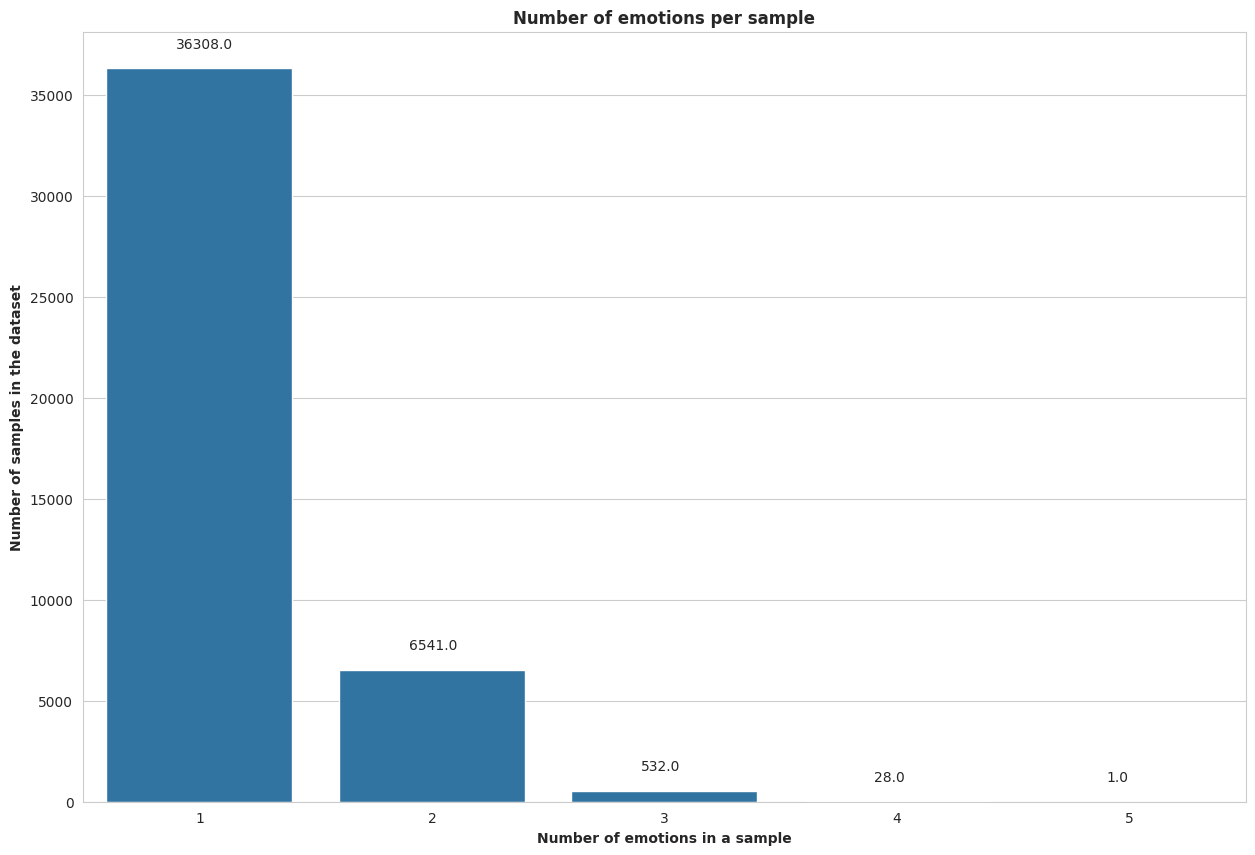

In [ ]:

# Cardinality of GoEmotions and Ekman labels across the dataset
plt.figure(figsize=(15,10))

ax = sns.countplot(x='Cardinality', data=train_GE)

for p in ax.patches:
  value = p.get_height()
  x = p.get_x() + p.get_width() - 0.5
  y = p.get_y() + p.get_height() + 1000
  ax.annotate(value, (x, y))


plt.title("Number of emotions per sample", fontweight='bold')
plt.ylabel("Number of samples in the dataset", fontweight='bold')
plt.xlabel("Number of emotions in a sample", fontweight='bold')
plt.show()

4.1.2 - Number of samples per emotion in the dataset

In [ ]:
# Computing number of samples per emotion
classes_GE_count = train_GE.loc[:,GE_taxonomy].sum(axis=0).sort_values(ascending=False)

/tmp/ipykernel_8970/671789866.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=classes_GE_count.values, y=classes_GE_count.index, orient='h', palette="Blues_d")


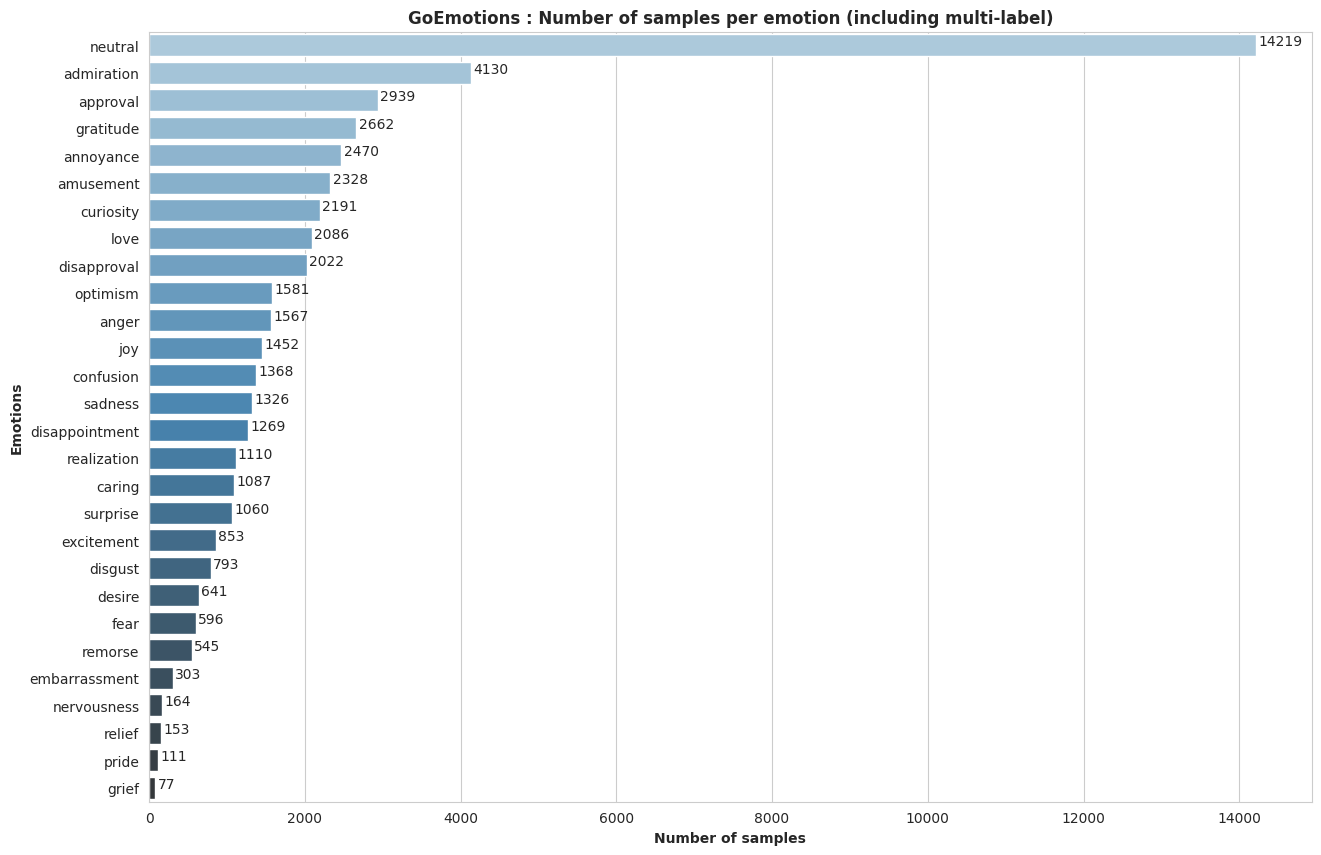

In [ ]:
# Visualizing the number of samples per classes
plt.figure(figsize=(15,10))
ax = sns.barplot(x=classes_GE_count.values, y=classes_GE_count.index, orient='h', palette="Blues_d")

for p in ax.patches:
  value = int(p.get_width())
  x = p.get_x() + p.get_width() + 30
  y = p.get_y() + p.get_height()/2
  ax.annotate(value, (x, y))

plt.title("GoEmotions : Number of samples per emotion (including multi-label)", fontweight='bold')
plt.ylabel("Emotions", fontweight='bold')
plt.xlabel("Number of samples", fontweight='bold')
plt.show()

4.1.3 - Classe balance accross train, validation and test datasets

In [ ]:
# Defining classes representation for each dataset (GoEmotions)
train_count_GE = (train_GE.loc[:, GE_taxonomy].sum(axis=0) / size_train)*100
val_count_GE = (val_GE.loc[:, GE_taxonomy].sum(axis=0) / size_val)*100
test_count_GE = (test_GE.loc[:, GE_taxonomy].sum(axis=0) / size_test)*100

# Constructing a unique dataset for visualization purposes
balance_GE = pd.DataFrame(data=[train_count_GE, val_count_GE, test_count_GE]).T.reset_index(drop=False)
balance_GE.columns = ['Emotion', 'Train', 'Validation', 'Test']
balance_GE = balance_GE.sort_values('Train', ascending=False)
balance_GE = balance_GE.melt(id_vars='Emotion', var_name='Dataset', value_vars=['Train','Validation', 'Test'], value_name='Percentage')

# Preview of data
display(balance_GE.head())

,Emotion,Dataset,Percentage
0,neutral,Train,32.755126
1,admiration,Train,9.513937
2,approval,Train,6.770329
3,gratitude,Train,6.132228
4,annoyance,Train,5.689933


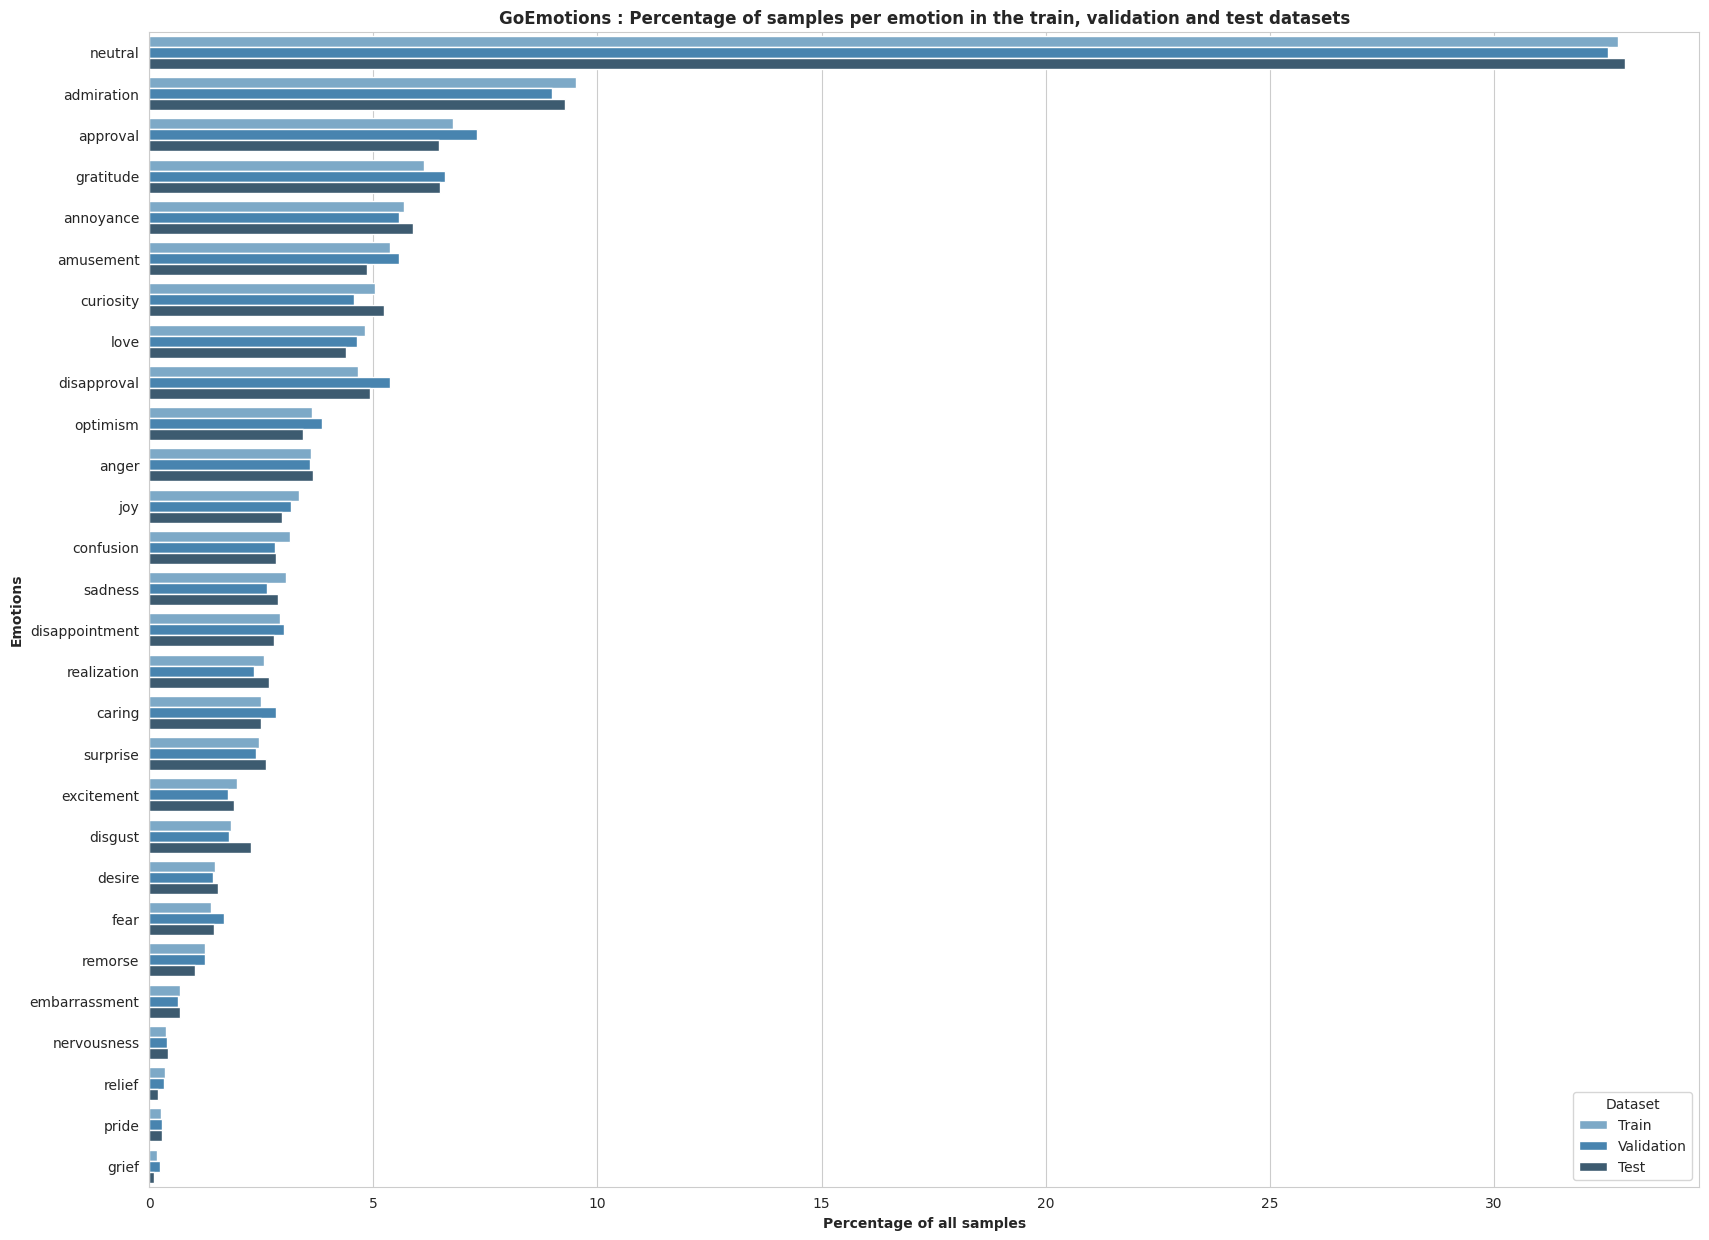

In [ ]:
# Classe Balance visualization on GoEmotions
plt.figure(figsize=(20,15))
sns.barplot(x='Percentage', y='Emotion', data=balance_GE, orient='h', hue='Dataset', palette="Blues_d")
plt.title("GoEmotions : Percentage of samples per emotion in the train, validation and test datasets", fontweight='bold')
plt.ylabel("Emotions", fontweight='bold')
plt.xlabel("Percentage of all samples", fontweight='bold')
plt.show()

4.2 - Words analysis

4.2.1 - Mean length of samples per emotion

In [ ]:
# Computing the number of words per sample
train_GE['Nb_words'] = train_GE['Clean_text'].apply(lambda x: len(x.split()))

# Preview of data
display(train_GE.head(3))

/tmp/ipykernel_8970/2535780199.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_GE['Nb_words'] = train_GE['Clean_text'].apply(lambda x: len(x.split()))


,Clean_text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,Cardinality,Nb_words
0,my favourite food is anything i did not have t...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,12
1,now if he does off himself everyone will think...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,20
2,why the fuck is bayless isoing,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,6


In [ ]:
# Computing the mean number of words per emotion
mean_nb_words = {}
for emo in GE_taxonomy:
  nb = train_GE['Nb_words'].loc[train_GE[emo]==1].mean()
  mean_nb_words[emo] = round(nb,2)

# Putting it in a Dataframe
df_length_GE = pd.DataFrame.from_dict(mean_nb_words, orient='index')
df_length_GE.columns = ['Mean_length']
df_length_GE.sort_values('Mean_length', ascending=False, inplace=True)

df_length_GE.head()

,Mean_length
optimism,16.37
realization,15.93
confusion,15.77
desire,15.28
disappointment,15.15


/tmp/ipykernel_8970/2659287416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=df_length_GE['Mean_length'], y=df_length_GE.index, orient='h', palette="Blues_d")


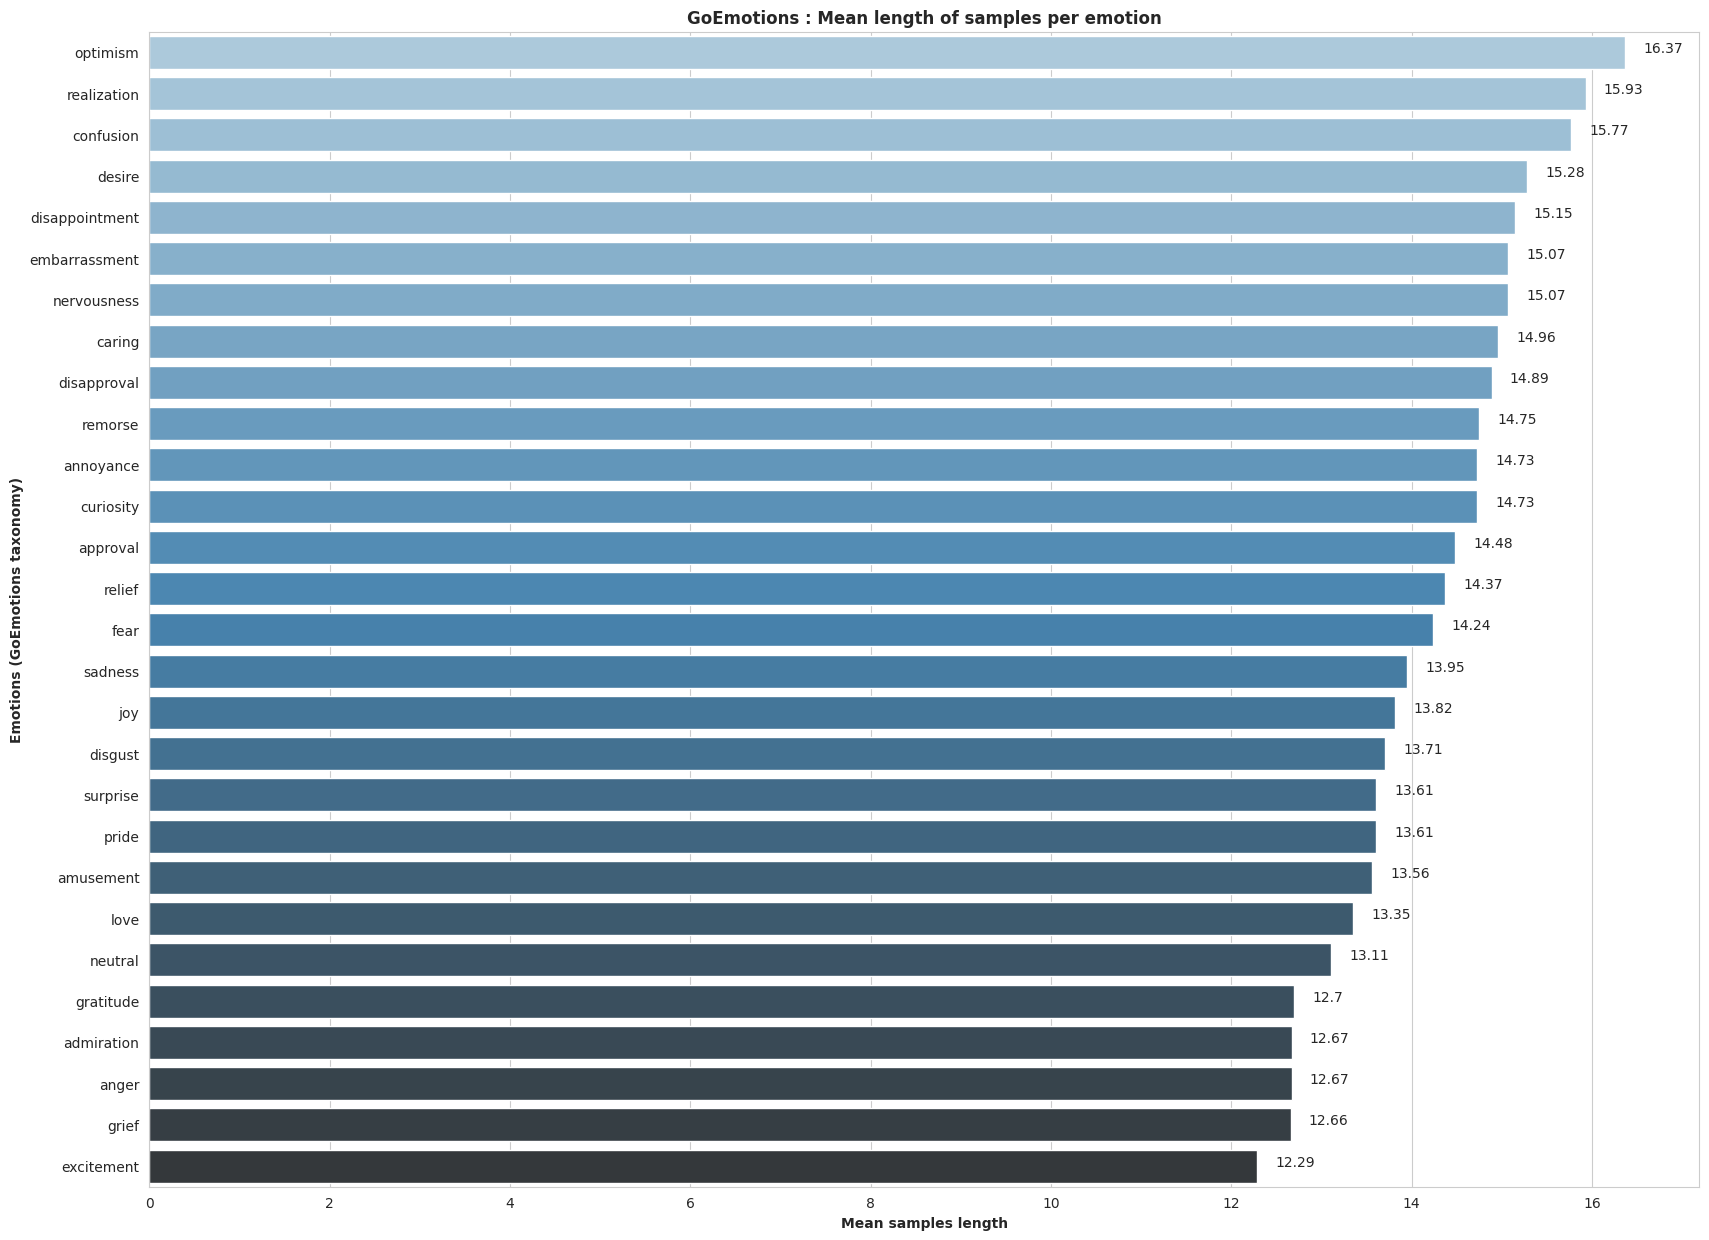

In [ ]:
# Visualizing the mean length of samples per emotion
plt.figure(figsize=(20,15))

ax = sns.barplot(x=df_length_GE['Mean_length'], y=df_length_GE.index, orient='h', palette="Blues_d")
for p in ax.patches:
  value = p.get_width()
  x = p.get_x() + p.get_width() + 0.2
  y = p.get_y() + p.get_height()/2
  ax.annotate(value, (x, y))

plt.title("GoEmotions : Mean length of samples per emotion", fontweight='bold')
plt.ylabel("Emotions (GoEmotions taxonomy)", fontweight='bold')
plt.xlabel("Mean samples length", fontweight='bold')
plt.show()


4.2.2 - Top words per emotion

In [ ]:
# Function to display 10 most frequent words in a list of comments
def plot_top_words_barchart(comments, axes):

    comments = comments.str.split() # split each comment into a list of words
    comments = comments.values.tolist() # from pandas series to lists of words
    corpus = [word for sample in comments for word in sample if word not in list(STOP_WORDS)+["?","!","name"]] # giant corpus of words excluding special characters
    counter = Counter(corpus) # create a counter
    most = counter.most_common(10) # retrieve the 10 most frequent words

    # Plot the 10 top words and their frequencies
    most = [(word, count) for (word, count) in most]
    x, y = [], []
    for word, count in most[:10]:
      x.append(word)
      y.append(count)
    sns.barplot(x=y, y=x , ax=axes, palette="Set2")


/tmp/ipykernel_8970/3081731972.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x , ax=axes, palette="Set2")
/tmp/ipykernel_8970/3081731972.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x , ax=axes, palette="Set2")
/tmp/ipykernel_8970/3081731972.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=y, y=x , ax=axes, palette="Set2")
/tmp/ipykernel_8970/3081731972.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `le

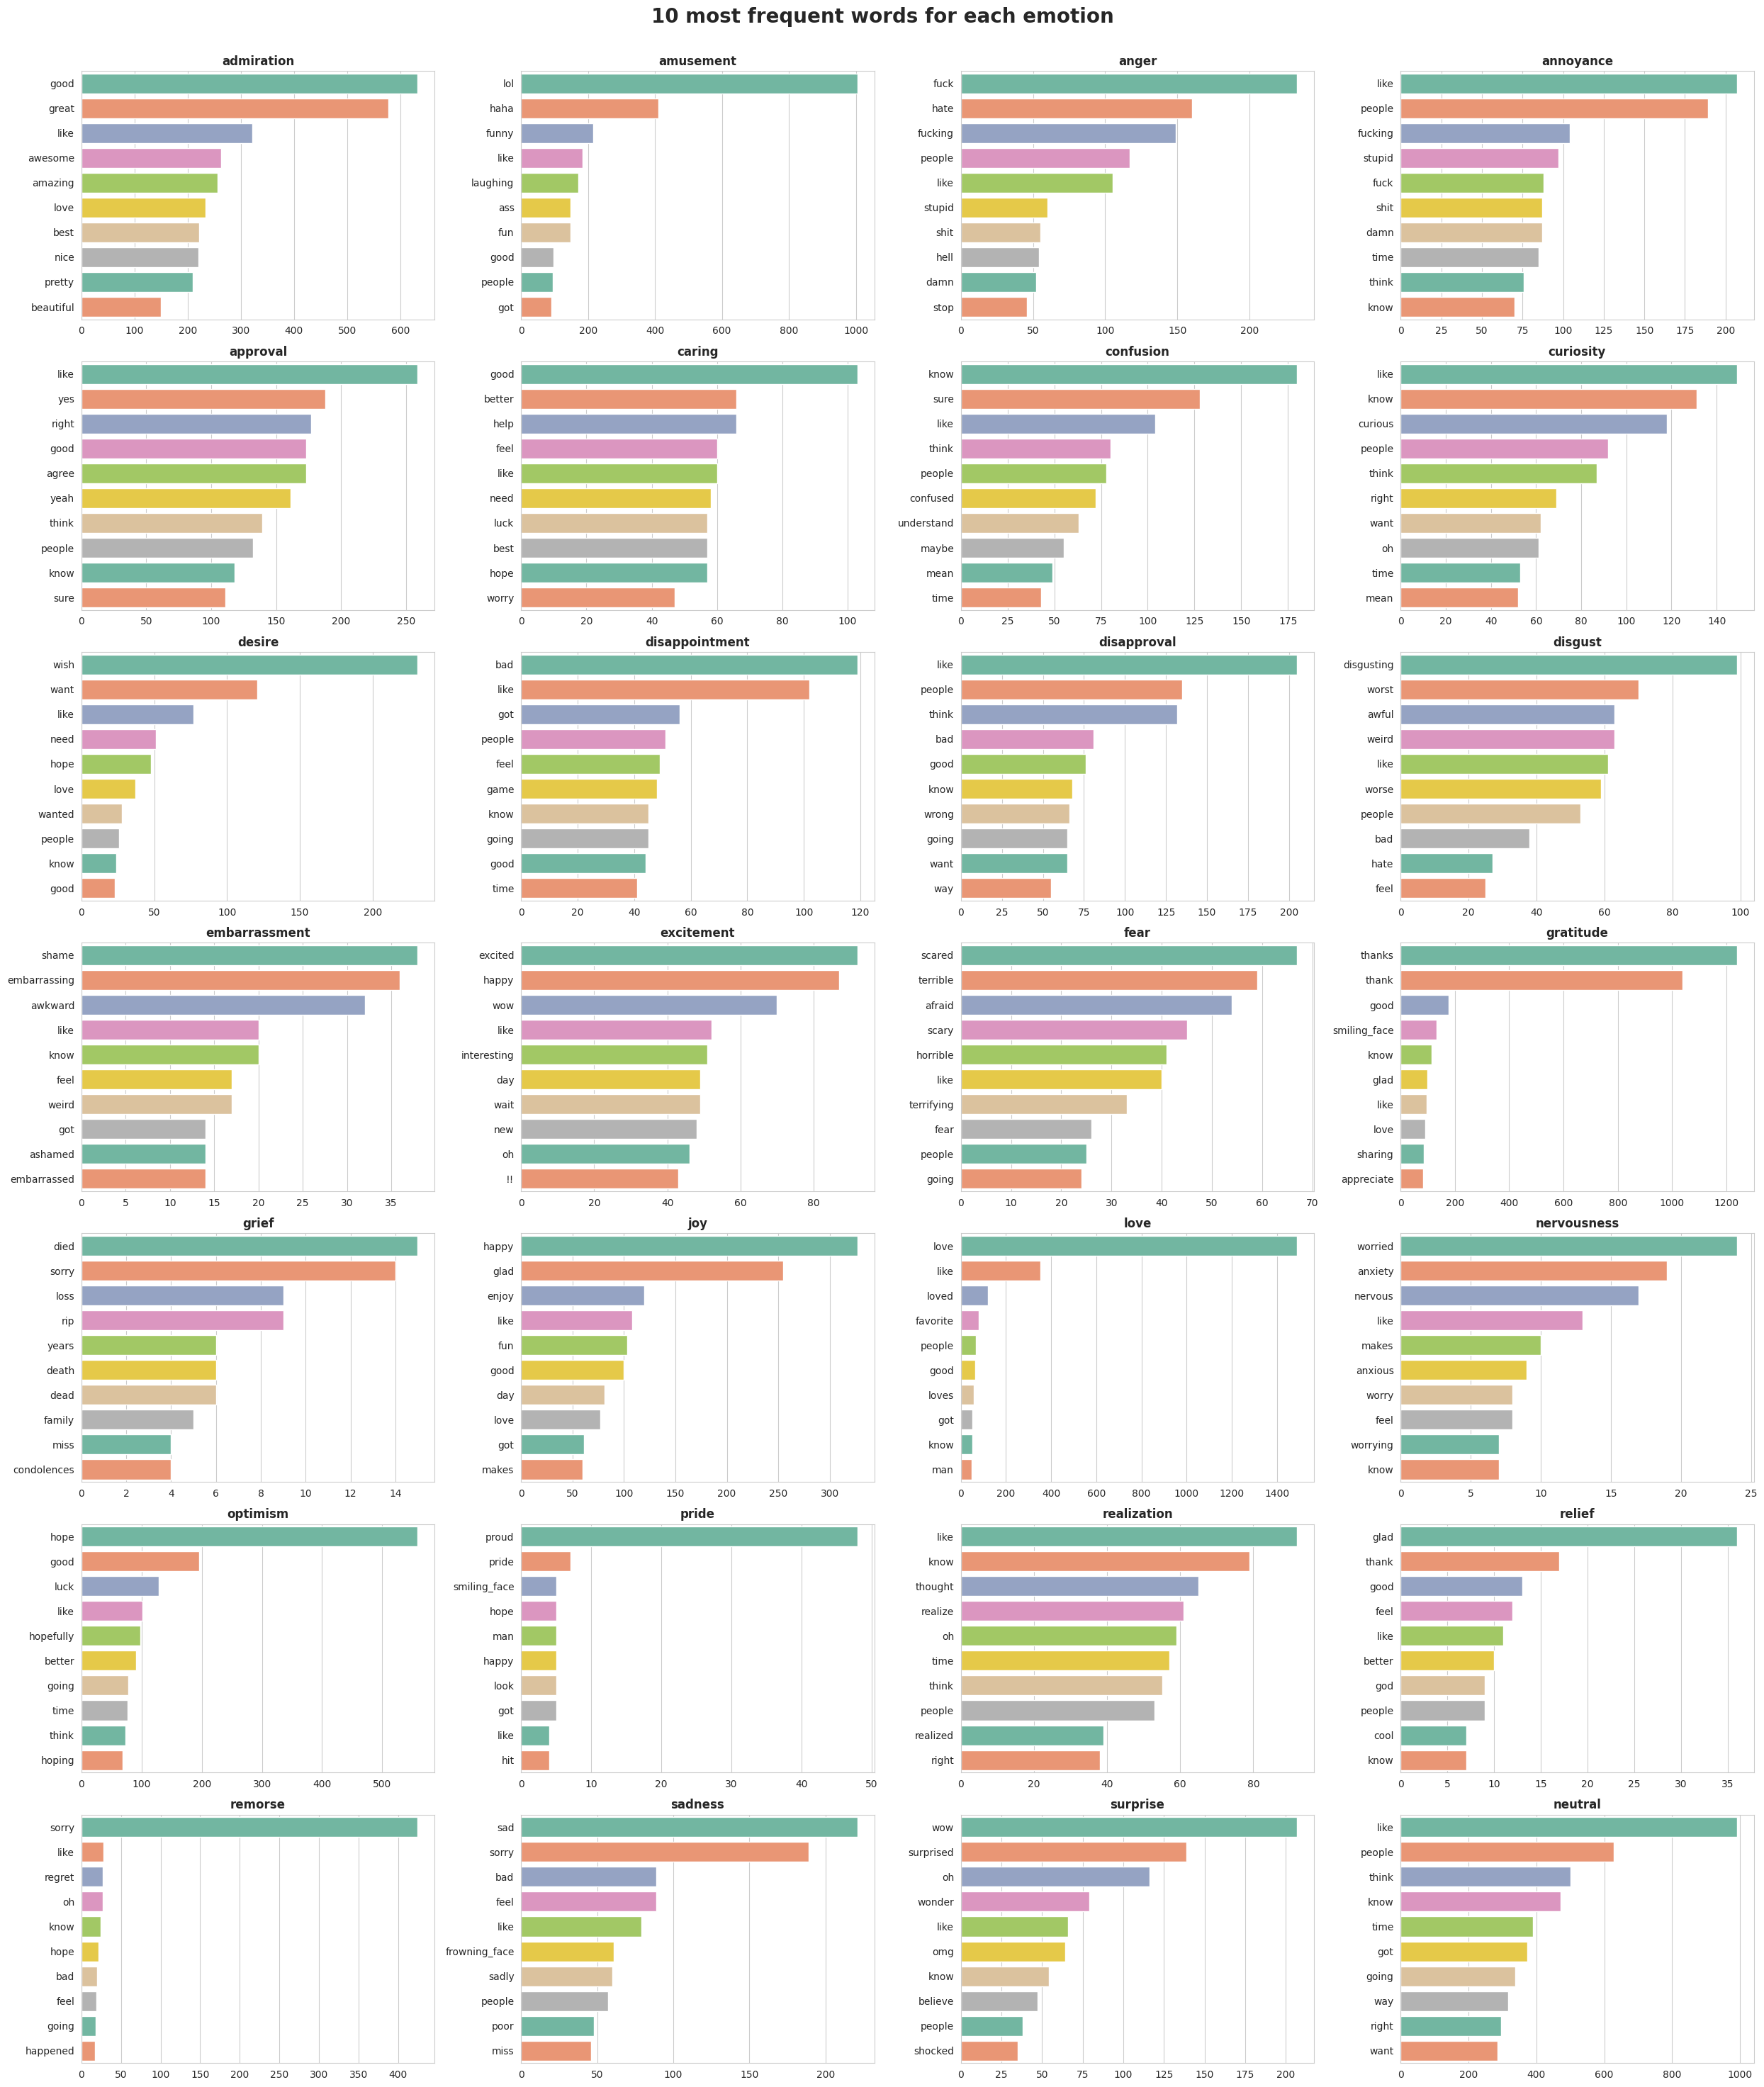

In [ ]:
# Displaying 10 most frequent words for each emotion
fig, axes = plt.subplots(7, 4, figsize=(25, 30))
fig.suptitle('10 most frequent words for each emotion', fontweight="bold", fontsize=20)

for i, axi in enumerate(axes.flat):
    plot_top_words_barchart(train_GE.loc[train_GE[GE_taxonomy[i]]==1,"Clean_text"], axi)
    axi.set_title(GE_taxonomy[i], fontweight="bold")

plt.tight_layout()
fig.subplots_adjust(top=0.95)
plt.show()


5 - Exporting Data

In [ ]:
# Droping unecessary columns
train_GE = train_GE[ ['Clean_text'] + GE_taxonomy ]

# Saving datasets for modeling
train_GE.to_csv("/content/drive/MyDrive/GoEmotions_Git/data/train_clean.csv", index = False)
val_GE.to_csv("/content/drive/MyDrive/GoEmotions_Git/data/val_clean.csv", index = False)
test_GE.to_csv("/content/drive/MyDrive/GoEmotions_Git/data/test_clean.csv", index = False)

In [ ]:
# Data manipulation libraries
import pandas as pd
import numpy as np
import json
from pprint import pprint

# Text processing libraries
import emoji
import re
import contractions
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

# Scikit-Learn packages
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import RidgeClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import precision_recall_fscore_support


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


In [ ]:
# Importing train, validation and test datasets with preprocessed texts and labels
train_GE = pd.read_csv("/content/drive/MyDrive/GoEmotions_Git/data/train_clean.csv")
val_GE = pd.read_csv("/content/drive/MyDrive/GoEmotions_Git/data/val_clean.csv")
test_GE = pd.read_csv("/content/drive/MyDrive/GoEmotions_Git/data/test_clean.csv")

# Shape validation
print(train_GE.shape)
print(val_GE.shape)
print(test_GE.shape)


(43410, 29)
(5426, 29)
(5427, 29)


In [ ]:
# Loading emotion labels for GoEmotions taxonomy
with open("/content/drive/MyDrive/unzipped_folder/data/emotions.txt", "r") as file:
    GE_taxonomy = file.read().split("\n")

for emo in GE_taxonomy:
  print(emo)

admiration
amusement
anger
annoyance
approval
caring
confusion
curiosity
desire
disappointment
disapproval
disgust
embarrassment
excitement
fear
gratitude
grief
joy
love
nervousness
optimism
pride
realization
relief
remorse
sadness
surprise
neutral


**2 - Preprocessings and transformations**

2.1 - Additional preprocessings for basic Machine Learning tasks

In [ ]:
# Additional text preprocessing
train_GE['Clean_text'] = train_GE['Clean_text'].apply(lambda x: re.sub(r"[^A-Za-z_]+"," ", x))
test_GE['Clean_text'] = test_GE['Clean_text'].apply(lambda x: re.sub(r"[^A-Za-z_]+"," ", x))

In [ ]:
# Download model
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 46.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Import English using en_core_web_sm.load()
import en_core_web_sm
nlp = en_core_web_sm.load()

In [ ]:
# Creating tokenized documents
tokenized_train_GE = train_GE["Clean_text"].apply(lambda desc: nlp(desc))
tokenized_test_GE = test_GE["Clean_text"].apply(lambda desc: nlp(desc))

In [ ]:
# Lemmatize each token and removing english stopwords
tokenized_train_GE = tokenized_train_GE.apply(lambda x: [token.lemma_ for token in x if token.lemma_ not in STOP_WORDS])
tokenized_test_GE = tokenized_test_GE.apply(lambda x: [token.lemma_ for token in x if token.lemma_ not in STOP_WORDS])

# Creating clean data in our dataframes
train_GE["Clean_token"] = [" ".join(x) for x in tokenized_train_GE]
test_GE["Clean_token"] = [" ".join(x) for x in tokenized_test_GE]

2.2 - Create TF-IDF matrix

In [ ]:
# TF-IDF vector with 1000 words vocabulary
vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)

# Fitting the vectorizer and transforming train and test data
tfidf_train_GE = vectorizer.fit_transform(train_GE['Clean_token'])
tfidf_test_GE = vectorizer.transform(test_GE['Clean_token'])

# Transforming from generators to arrays
tfidf_train_GE = tfidf_train_GE.toarray()
tfidf_test_GE = tfidf_test_GE.toarray()

# Validating the shape of train and test data
print(tfidf_train_GE.shape)
print(tfidf_test_GE.shape)

(43410, 1000)
(5427, 1000)


2.3 - Train and test variables

In [ ]:
# Defining train and test variables
X_train =  tfidf_train_GE
y_train = train_GE.loc[:,GE_taxonomy].values

X_test =  tfidf_test_GE
y_test = test_GE.loc[:,GE_taxonomy].values

# Shape validation
print("The shape of X_train is : ", X_train.shape)
print("The shape of y_train is : ", y_train.shape)
print()
print("The shape of X_test is : ", X_test.shape)
print("The shape of y_test is : ", y_test.shape)

The shape of X_train is :  (43410, 1000)
The shape of y_train is :  (43410, 28)

The shape of X_test is :  (5427, 1000)
The shape of y_test is :  (5427, 28)


3 - Dummy model

3.1 - Simulating dummy predictions

In [ ]:
# Preview of data
display(train_GE.head(3))

,Clean_text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,desire,...,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral,Clean_token
0,my favourite food is anything i did not have t...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,favourite food I cook
1,now if he does off himself everyone will think...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,think s laugh screw people instead actually dead
2,why the fuck is bayless isoing,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,fuck bayless isoing


In [ ]:
# Always predicting neutral emotion
dummy_preds = np.zeros_like(y_test)
dummy_preds[:,-1] = 1
dummy_preds

array([[0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1],
       [0, 0, 0, ..., 0, 0, 1]])

3.2 - Evaluation on GoEmotions taxonomy

In [ ]:
# Model evaluation function
def model_eval(y_true, y_pred_labels, emotions):

    # Defining variables
    precision = []
    recall = []
    f1 = []

    # Per emotion evaluation
    idx2emotion = {i: e for i, e in enumerate(emotions)}

    for i in range(len(emotions)):

        # Computing precision, recall and f1-score
        p, r, f1_score, _ = precision_recall_fscore_support(y_true[:, i], y_pred_labels[:, i], average="binary")

        # Append results in lists
        precision.append(round(p, 2))
        recall.append(round(r, 2))
        f1.append(round(f1_score, 2))

    # Macro evaluation
    macro_p, macro_r, macro_f1_score, _ = precision_recall_fscore_support(y_true, y_pred_labels, average="macro")

    # Append results in lists
    precision.append(round(macro_p, 2))
    recall.append(round(macro_r, 2))
    f1.append(round(macro_f1_score, 2))

    # Converting results to a dataframe
    df_results = pd.DataFrame({"Precision":precision, "Recall":recall, 'F1':f1})
    df_results.index = emotions+['MACRO-AVERAGE']

    return df_results

In [ ]:
# Model evaluation
model_eval(y_test, dummy_preds, GE_taxonomy)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

,Precision,Recall,F1
admiration,0.00,0.00,0.00
amusement,0.00,0.00,0.00
anger,0.00,0.00,0.00
annoyance,0.00,0.00,0.00
approval,0.00,0.00,0.00
caring,0.00,0.00,0.00
confusion,0.00,0.00,0.00
curiosity,0.00,0.00,0.00
desire,0.00,0.00,0.00
disappointment,0.00,0.00,0.00


4 - Baseline model: Ridge Classifier

4.1 - Training the model and evaluation on GoEmotions taxonomy

In [ ]:
# Multi-label classification
rc = RidgeClassifier(class_weight='balanced')
classifier = MultiOutputClassifier(rc, n_jobs=-1)
classifier.fit(X_train, y_train)

MultiOutputClassifier(estimator=RidgeClassifier(class_weight='balanced'),
                      n_jobs=-1)

In [ ]:
# Making predictions on GoEmotions taxonomy
classifier_preds = classifier.predict(X_test)
classifier_preds


array([[0, 0, 0, ..., 1, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 1],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 1]])

In [ ]:
# Model evaluation
model_eval(y_test, classifier_preds, GE_taxonomy)

,Precision,Recall,F1
admiration,0.38,0.72,0.50
amusement,0.58,0.90,0.70
anger,0.15,0.63,0.24
annoyance,0.14,0.59,0.22
approval,0.15,0.66,0.24
caring,0.08,0.60,0.14
confusion,0.07,0.62,0.13
curiosity,0.08,0.57,0.15
desire,0.11,0.70,0.18
disappointment,0.06,0.50,0.10


4.2 - Make predictions

In [ ]:
# Retrieving initial text preprocessings
def preprocess_corpus(x):

    # Adding a space between words and punctation
    x = re.sub( r'([a-zA-Z\n])([,;.!?])', r'\1 \2', x)
    x = re.sub( r'([,;.!?])([a-zA-Z\n])', r'\1 \2', x)

    # Demojize
    x = emoji.demojize(x)

    # Expand contraction
    x = contractions.fix(x)

    # Lower
    x = x.lower()

    #correct some acronyms/typos/abbreviations
    x = re.sub(r"lmao", "laughing my ass off", x)
    x = re.sub(r"amirite", "am i right", x)
    x = re.sub(r"\b(tho)\b", "though", x)
    x = re.sub(r"\b(ikr)\b", "i know right", x)
    x = re.sub(r"\b(ya|u)\b", "you", x)
    x = re.sub(r"\b(eu)\b", "europe", x)
    x = re.sub(r"\b(da)\b", "the", x)
    x = re.sub(r"\b(dat)\b", "that", x)
    x = re.sub(r"\b(dats)\b", "that is", x)
    x = re.sub(r"\b(cuz)\b", "because", x)
    x = re.sub(r"\b(fkn)\b", "fucking", x)
    x = re.sub(r"\b(tbh)\b", "to be honest", x)
    x = re.sub(r"\b(tbf)\b", "to be fair", x)
    x = re.sub(r"faux pas", "mistake", x)
    x = re.sub(r"\b(btw)\b", "by the way", x)
    x = re.sub(r"\b(bs)\b", "bullshit", x)
    x = re.sub(r"\b(kinda)\b", "kind of", x)
    x = re.sub(r"\b(bruh)\b", "bro", x)
    x = re.sub(r"\b(w/e)\b", "whatever", x)
    x = re.sub(r"\b(w/)\b", "with", x)
    x = re.sub(r"\b(w/o)\b", "without", x)
    x = re.sub(r"\b(doj)\b", "department of justice", x)

    # replace some words with multiple occurences of a letter, example "coooool" turns into --> cool
    x = re.sub(r"\b(j+e{2,}z+e*)\b", "jeez", x)
    x = re.sub(r"\b(co+l+)\b", "cool", x)
    x = re.sub(r"\b(g+o+a+l+)\b", "goal", x)
    x = re.sub(r"\b(s+h+i+t+)\b", "shit", x)
    x = re.sub(r"\b(o+m+g+)\b", "omg", x)
    x = re.sub(r"\b(w+t+f+)\b", "wtf", x)
    x = re.sub(r"\b(w+h+a+t+)\b", "what", x)
    x = re.sub(r"\b(y+e+y+|y+a+y+|y+e+a+h+)\b", "yeah", x)
    x = re.sub(r"\b(w+o+w+)\b", "wow", x)
    x = re.sub(r"\b(w+h+y+)\b", "why", x)
    x = re.sub(r"\b(s+o+)\b", "so", x)
    x = re.sub(r"\b(f)\b", "fuck", x)
    x = re.sub(r"\b(w+h+o+p+s+)\b", "whoops", x)
    x = re.sub(r"\b(ofc)\b", "of course", x)
    x = re.sub(r"\b(the us)\b", "usa", x)
    x = re.sub(r"\b(gf)\b", "girlfriend", x)
    x = re.sub(r"\b(hr)\b", "human ressources", x)
    x = re.sub(r"\b(mh)\b", "mental health", x)
    x = re.sub(r"\b(idk)\b", "i do not know", x)
    x = re.sub(r"\b(gotcha)\b", "i got you", x)
    x = re.sub(r"\b(y+e+p+)\b", "yes", x)
    x = re.sub(r"\b(a*ha+h[ha]*|a*ha +h[ha]*)\b", "haha", x)
    x = re.sub(r"\b(o?l+o+l+[ol]*)\b", "lol", x)
    x = re.sub(r"\b(o*ho+h[ho]*|o*ho +h[ho]*)\b", "ohoh", x)
    x = re.sub(r"\b(o+h+)\b", "oh", x)
    x = re.sub(r"\b(a+h+)\b", "ah", x)
    x = re.sub(r"\b(u+h+)\b", "uh", x)

    # Handling emojis
    x = re.sub(r"<3", " love ", x)
    x = re.sub(r"xd", " smiling_face_with_open_mouth_and_tightly_closed_eyes ", x)
    x = re.sub(r":\)", " smiling_face ", x)
    x = re.sub(r"^_^", " smiling_face ", x)
    x = re.sub(r"\*_\*", " star_struck ", x)
    x = re.sub(r":\(", " frowning_face ", x)
    x = re.sub(r":\^\(", " frowning_face ", x)
    x = re.sub(r";\(", " frowning_face ", x)
    x = re.sub(r":\/",  " confused_face", x)
    x = re.sub(r";\)",  " wink", x)
    x = re.sub(r">__<",  " unamused ", x)
    x = re.sub(r"\b([xo]+x*)\b", " xoxo ", x)
    x = re.sub(r"\b(n+a+h+)\b", "no", x)

    # Handling special cases of text
    x = re.sub(r"h a m b e r d e r s", "hamberders", x)
    x = re.sub(r"b e n", "ben", x)
    x = re.sub(r"s a t i r e", "satire", x)
    x = re.sub(r"y i k e s", "yikes", x)
    x = re.sub(r"s p o i l e r", "spoiler", x)
    x = re.sub(r"thankyou", "thank you", x)
    x = re.sub(r"a^r^o^o^o^o^o^o^o^n^d", "around", x)

    # Remove special characters and numbers replace by space + remove double space
    x = re.sub(r"\b([.]{3,})"," dots ", x)
    x = re.sub(r"[^A-Za-z!?_]+"," ", x)
    x = re.sub(r"\b([s])\b *","", x)
    x = re.sub(r" +"," ", x)
    x = x.strip()

    return x

In [ ]:
def predict_samples(text_samples, model):

    # Text preprocessing and cleaning
    text_samples = pd.Series(text_samples)
    text_samples_clean = text_samples.apply(preprocess_corpus)

    # Create tfidf representation
    tfidf_text_samples_clean = vectorizer.transform(text_samples_clean)

    # labels predictions
    samples_pred_labels = model.predict(tfidf_text_samples_clean)
    samples_pred_labels_df = pd.DataFrame(samples_pred_labels)
    samples_pred_labels_df = samples_pred_labels_df.apply(lambda x: [GE_taxonomy[i] for i in range(len(x)) if x[i]==1], axis=1)

    return pd.DataFrame({"Text":text_samples, "Emotions":list(samples_pred_labels_df)})

In [ ]:
# Predict samples
predict_samples("no one cares my guy", classifier)


,Text,Emotions
0,no one cares my guy,"[curiosity, neutral]"
